      inflation                total-supply                      bonded  \
0        263500  25788943333701330868794873  12585251878818444079844996   
1        264000  25795424143622158931881697  12588875719280015087163317   
2        264500  25801431400633967933630602  12595130488385479352898022   
3        265000  25807997973578028153604960  12600920865737280552557772   
4        265500  25814292519569928839182386  12606903199792140445140912   
...         ...                         ...                         ...   
1234     688500  46632370371125655441169350  23826312379944045771498915   
1235     688000  46664942141166359851299574  23915921058787672821407142   
1236     687500  46696901960461201232959138  23960751150002227623846439   
1237     687000  46728766819949288836532181  23997084492334907531623568   
1238     686500  46759749687946016451393991  24058612609986797033112978   

           date      block  
0    2022-07-01   16662053  
1    2022-07-02   16762407  
2    2022-07

/var/folders/y1/jd5q6cmx1ll8srvwktxq_r980000gn/T/ipykernel_46018/3647344542.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


✅ Saved dataset
         date fear_greed_index  btc_price_usd  eth_price_usd  lpt_price_usd  \
0  2022-07-01               11   19269.367188    1059.767334       8.390814   
1  2022-07-02               14   19242.255859    1066.512817       8.325410   
2  2022-07-03               11   19297.076172    1073.766968       8.200625   
3  2022-07-04               14   20231.261719    1151.059082       8.523345   
4  2022-07-05               19   20190.115234    1134.541016       8.339983   

    btc_volume   eth_volume  lpt_volume  inflation  \
0  30767551159  17499453625    24563338     263500   
1  18100418740   9935603640    19949172     264000   
2  16390821947   8557248150    17491867     264500   
3  21594638208  13670889311    19494446     265000   
4  26715546990  16195518291    20236766     265500   

                 total-supply                      bonded     block  
0  25788943333701330868794873  12585251878818444079844996  16662053  
1  25795424143622158931881697  1258887571928

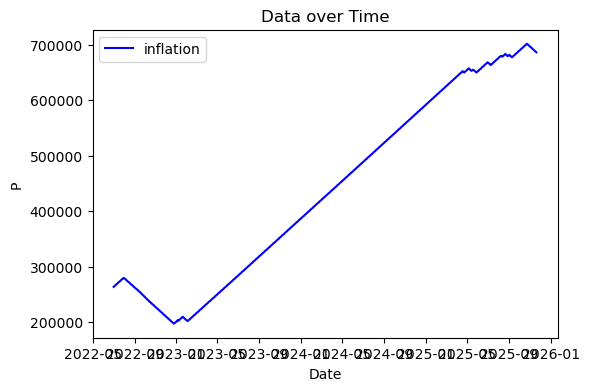

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Open and read the JSON file
with open('/Users/sazisbekuu/Downloads/ShtukaResearch/lpt-daily-data-22-25.json', 'r') as file:
    data = json.load(file)

# Now `data` is a Python dictionary (or list, depending on the JSON structure)
data = pd.DataFrame(data)
#print(data['bonded']/data['total-supply']) #
#print(data['inflation']/1e9 * data['total-supply']) # new minted tokens
#print(data['inflation']/1e9 * 365)

dates = pd.date_range(start=data['date'].iloc[0], end=data['date'].iloc[-1], freq='D')
data['date'] = dates
print(data)


# Plot DataFrame
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(data['date'], data['inflation'], label="inflation", color="blue")
ax.set_title("Data over Time")
ax.set_xlabel("Date")
ax.set_ylabel("P")
ax.legend()


import yfinance as yf

# 1. Define tickers and date range
TICKERS = ["LPT-USD", "BTC-USD", "ETH-USD"]
START = data['date'].iloc[0].strftime("%Y-%m-%d")
END   = data['date'].iloc[-1].strftime("%Y-%m-%d")

# 2. Fetch OHLCV data
df = yf.download(
    TICKERS,
    start=START,
    end=END,
    interval="1d",
    progress=False
)

# 3. Extract Close prices
df_close = df["Close"].reset_index()
df_close.rename(columns={
    "Date": "date",
    "LPT-USD": "lpt_price_usd",
    "BTC-USD": "btc_price_usd",
    "ETH-USD": "eth_price_usd"
}, inplace=True)

# 4. Extract Volumes
df_vol = df["Volume"].reset_index()
df_vol.rename(columns={
    "Date": "date",
    "LPT-USD": "lpt_volume",
    "BTC-USD": "btc_volume",
    "ETH-USD": "eth_volume"
}, inplace=True)

# 5. Merge on date
df = pd.merge(df_close, df_vol, on="date", how="inner")

# 6. (Optional) ensure date is a plain date, not Timestamp
df["date"] = pd.to_datetime(df["date"]).dt.date

# 7. Save to CSV
#df_2024.to_csv("crypto_2024_prices_volumes.csv", index=False)

print("✅ Saved 2024 daily price & volume data to crypto_2024_prices_volumes.csv")



import requests
from datetime import datetime

def fetch_fear_greed_index(start_date, end_date):
    url = "https://api.alternative.me/fng/?limit=0&date_format=unix"
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json().get('data', [])
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y').dt.date
    df = df[['date', 'value']].rename(columns={'value': 'fear_greed_index'})
    return df[(df['date'] >= start_date) & (df['date'] <= end_date)]

# Assemble data
start = datetime.strptime(START, '%Y-%m-%d').date()
end   = datetime.strptime(END, '%Y-%m-%d').date()

df_fng = fetch_fear_greed_index(start, end)
df_fng = df_fng.iloc[::-1].reset_index(drop=True)

df_fng['date'] = pd.to_datetime(df_fng['date']).dt.date
data['date'] = pd.to_datetime(data['date']).dt.date


df_final = df_fng.merge(df, on='date', how='inner')

df_final = df_final.merge(data, on='date', how='inner')

# Save
df_final.to_csv('Data2022-2025.csv', index=False)
print("✅ Saved dataset")

print(df_final.head(), df_final.shape)



Per-round dataset generation (from daily data)

1) Start with the merged daily dataset (`df_final`).
2) Fill missing numeric values via linear interpolation.
3) Create a day index (1..N) to represent each daily row.
4) Convert day indices to round positions using ~1.142857 rounds/day (24 rounds per 21 hours).
5) Generate evenly spaced round positions across the full time range.
6) Interpolate each numeric column from day positions to round positions.
7) Build an alternative nearest-neighbor dataset to preserve date labels.
8) Save the nearest-neighbor round dataset as `Data2022-2025[perRound].csv`.


In [14]:
# Build a per-round dataset from daily rows.
# We treat each day as 24/21 rounds (~1.142857) to match protocol timing.
# Steps:
# - Interpolate missing numeric values across days.
# - Create a day index (1..N) and map it to round positions.
# - Interpolate numeric columns to those round positions.
# - Use nearest-neighbor sampling for the date column.
# - Save the nearest-neighbor round dataset.

rounds_per_day = 24 / 21  # ~1.142857

df = df_final.copy()

# Fill NaNs using linear interpolation
df = df.interpolate(method='linear')

df['day_idx'] = range(1, len(df) + 1)
df['round_idx']  = df['day_idx'] * rounds_per_day
cols = [col for col in df.columns if col != 'date']


df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')


# Create round positions (417 rounds evenly spaced across the year)
round_positions = np.linspace(df['day_idx'].min(), df['day_idx'].max(), int(24/21 * len(df)))

# Interpolate all numeric columns except 'day_num'
numeric_cols = df.select_dtypes(include='number').columns.drop('day_idx')

# Perform interpolation for each numeric column
round_data = {}
for col in cols:
    round_data[col] = np.interp(round_positions, df['day_idx'], df[col])

# Create new DataFrame for rounds
round_df = pd.DataFrame(round_data)
round_df.insert(0, 'round', range(1, len(round_df) + 1))

print("Original daily DataFrame shape:", df.shape)
print("Interpolated round-based DataFrame shape:", round_df.shape)
print(round_df.head())




# Interpolate using nearest method
round_data = {}
for col in cols:
    # Find nearest index for each round position
    nearest_idx = np.abs(df['day_idx'].values[:, None] - round_positions).argmin(axis=0)
    round_data[col] = df[col].iloc[nearest_idx].values

# Trying to include date column too
nearest_idx = np.abs(df['day_idx'].values[:, None] - round_positions).argmin(axis=0)
round_data['date'] = df['date'].iloc[nearest_idx].values


# Create new DataFrame for rounds
round_df = pd.DataFrame(round_data)
round_df.insert(0, 'round', range(1, len(round_df) + 1))

print(round_df.head())

# Save
round_df.to_csv('Data2022-2025[perRound].csv', index=False)
print("✅ Saved dataset")


Original daily DataFrame shape: (1237, 14)
Interpolated round-based DataFrame shape: (1413, 14)
   round  fear_greed_index  btc_price_usd  eth_price_usd  lpt_price_usd  \
0      1         11.000000   19269.367188    1059.767334       8.390814   
1      2         13.626062   19245.635175    1065.672021       8.333562   
2      3         11.747875   19283.409918    1071.958568       8.231733   
3      4         12.878187   19881.934545    1122.156648       8.402668   
4      5         16.507082   20210.630195    1142.776652       8.431404   

     btc_volume    eth_volume    lpt_volume      inflation  total-supply  \
0  3.076755e+10  1.749945e+10  2.456334e+07  263500.000000  2.578894e+25   
1  1.967932e+10  1.087841e+10  2.052431e+07  263937.677054  2.579462e+25   
2  1.681701e+10  8.900861e+09  1.810445e+07  264375.354108  2.579993e+25   
3  1.964874e+10  1.175871e+10  1.874561e+07  264813.031161  2.580554e+25   
4  2.416235e+10  1.493678e+10  1.986666e+07  265250.708215  2.581115e+25 

/var/folders/y1/jd5q6cmx1ll8srvwktxq_r980000gn/T/ipykernel_46018/620921497.py:6: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')


In [7]:
# Open and read the JSON file
with open('/Users/sazisbekuu/Downloads/ShtukaResearch/lpt-daily-data-22-25.json', 'r') as file:
    data = json.load(file)

# Now `data` is a Python dictionary (or list, depending on the JSON structure)
data = pd.DataFrame(data)


,inflation,total-supply,bonded,date,block
0,263500,25788943333701330868794873,12585251878818444079844996,2022-07-01,16662053
1,264000,25795424143622158931881697,12588875719280015087163317,2022-07-02,16762407
2,264500,25801431400633967933630602,12595130488385479352898022,2022-07-03,16855480
3,265000,25807997973578028153604960,12600920865737280552557772,2022-07-04,16934137
4,265500,25814292519569928839182386,12606903199792140445140912,2022-07-05,17014937
...,...,...,...,...,...
1234,688500,46632370371125655441169350,23826312379944045771498915,2025-11-16,400677956
1235,688000,46664942141166359851299574,23915921058787672821407142,2025-11-17,401023371
1236,687500,46696901960461201232959138,23960751150002227623846439,2025-11-18,401369181
1237,687000,46728766819949288836532181,23997084492334907531623568,2025-11-19,401714884
